In [1]:
print("Hola Luristán")

Hola Luristán


In [2]:
### IMPORTS ###
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import optuna
from optuna.pruners import MedianPruner
import xgboost as xgb
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, matthews_corrcoef
)
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import missingno as msno
import seaborn as sns
from sklearn.impute import SimpleImputer, MissingIndicator

warnings.filterwarnings('ignore')

# HARDWARE DETECTION
# Detects GPU availability to adjust the number of Optuna trials.
try:
    import torch
    USE_GPU = torch.cuda.is_available()
    device_info = torch.cuda.get_device_name(0) if USE_GPU else "No GPU detected"
except ImportError:
    USE_GPU = False
    device_info = "No GPU detected (torch not installed)"

print(f"Device: {device_info}")
N_TRIALS_PER_MODEL = 50 if USE_GPU else 20
print(f"N_TRIALS_PER_MODEL set to {N_TRIALS_PER_MODEL}")

c:\Users\Jon Uni\miniconda3\envs\advancedML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: NVIDIA GeForce RTX 5080
N_TRIALS_PER_MODEL set to 50


DATA PROCESSING

In [3]:
### DATASET LOADING ###

#Lo antiguo de Jon
#gauth = GoogleAuth()
#gauth.LocalWebserverAuth()
#drive = GoogleDrive(gauth)

# Google Drive ID for public sharing of the dataset
#file_id = "1aGGJNl1VtET_6HqQh81ouSKqe6-lN-OG"
#file = drive.CreateFile({"id": file_id})
#file.GetContentFile("ai_tools.csv")

# Reading the csv and loading it into a pandas dataframe.
#df = pd.read_csv("ai_tools.csv")
#df.head()

url = "https://raw.githubusercontent.com/GafillaAbrahamer/ClassificationProject/refs/heads/main/AI_Landscape_19k_Tools_2026.csv"
df = pd.read_csv(url)
df.head()

# The target is already a categorical multiclass column — no transformation needed.
# Classes: "Free", "Freemium", "Subscription", "Pay-as-you-go", "Open Source", "Usage-Based"

# We remove the target from the features to avoid data leakage.
X = df.drop(["Pricing_Model"], axis=1)

# We only keep the label.
y = df["Pricing_Model"]

print(X)
print(y)

               AI_Name     Developer  Release_Year  \
0             Scrip Ai       Scripai          2024   
1             Quickads      Quickads          2025   
2           Wonderchat    Wonderchat          2024   
3         Creatosaurus  Creatosaurus          2023   
4                Blobr         Blobr          2025   
...                ...           ...           ...   
19324         Emozi Ai         Emozi          2025   
19325        Myresumai     Myresumai          2022   
19326  Code Screenshot            Cs          2024   
19327      Ho Ho Hello     Hohohello          2022   
19328             Puti          Puti          2024   

                 Intelligence_Type Primary_Domain  \
0                 Generative Video          Video   
1      Computer Vision / Diffusion   Image/Design   
2         Multimodal Generative AI  General/Other   
3                 Autonomous Agent     Automation   
4                 Autonomous Agent     Automation   
...                            ..

In [4]:
### MISSING DATA ANALYSIS ###

# Total missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Percentage of missing values per column
print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Quick summary: any missing at all?
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
AI_Name                 0
Developer               0
Release_Year            0
Intelligence_Type       0
Primary_Domain          0
Key_Functionality       0
Pricing_Model           0
API_Availability        0
Context_Window       3877
Accessibility           0
Website_URL             0
Popularity_Votes        0
dtype: int64

Missing values (%):
AI_Name               0.00
Developer             0.00
Release_Year          0.00
Intelligence_Type     0.00
Primary_Domain        0.00
Key_Functionality     0.00
Pricing_Model         0.00
API_Availability      0.00
Context_Window       20.06
Accessibility         0.00
Website_URL           0.00
Popularity_Votes      0.00
dtype: float64

Total missing values in dataset: 3877


In [5]:
### TRANSFORMATION PIPELINE ###
# We drop non-informative columns
cols_to_drop = ['AI_Name', 'Developer', 'Website_URL', 'Key_Functionality']
X = df.drop(columns=cols_to_drop + ['Pricing_Model'])

# Train / Validation / Test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
X_train['Context_Window'] = X_train['Context_Window'].fillna('N/A')
X_val['Context_Window']   = X_val['Context_Window'].fillna('N/A')
X_test['Context_Window']  = X_test['Context_Window'].fillna('N/A')

print(f"Train size:      {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size:       {X_test.shape[0]}")

# We define column groups for encoding
ordinal_cols = ['Context_Window']
ordinal_categories = [['N/A', '8k', '32k', '128k', '1M']]  # explicit order

onehot_cols = ['Intelligence_Type', 'Primary_Domain', 'API_Availability', 'Accessibility']

numerical_cols = ['Release_Year', 'Popularity_Votes']

# we build the ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    ('scaler', StandardScaler(), numerical_cols),
])

# we fit ONLY on train, then transform each split
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

# Optional: recover a readable DataFrame
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
feature_names = ordinal_cols + list(onehot_feature_names) + numerical_cols

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_processed   = pd.DataFrame(X_val_processed,   columns=feature_names)
X_test_processed  = pd.DataFrame(X_test_processed,  columns=feature_names)

print(X_train_processed.head())
print(f"\nFinal shape — Train: {X_train_processed.shape}, Val: {X_val_processed.shape}, Test: {X_test_processed.shape}")

Train size:      15463
Validation size: 1933
Test size:       1933
   Context_Window  Intelligence_Type_Autonomous Agent  \
0             3.0                                 0.0   
1             0.0                                 1.0   
2             3.0                                 0.0   
3             3.0                                 0.0   
4             4.0                                 0.0   

   Intelligence_Type_Code Intelligence  \
0                                  0.0   
1                                  0.0   
2                                  0.0   
3                                  0.0   
4                                  0.0   

   Intelligence_Type_Computer Vision / Diffusion  \
0                                            0.0   
1                                            0.0   
2                                            0.0   
3                                            1.0   
4                                            0.0   

   Intelligence_Type_Gen

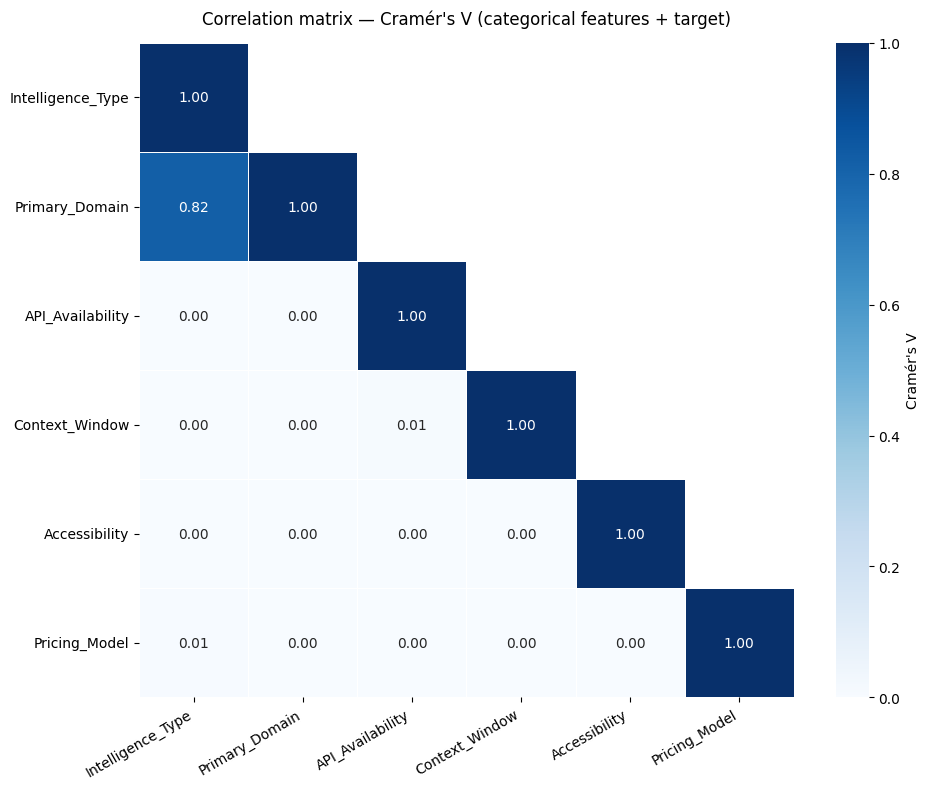


Cramér's V con Pricing_Model (target):
Intelligence_Type    0.007
Accessibility        0.002
Primary_Domain       0.000
API_Availability     0.000
Context_Window       0.000


In [6]:
### CORRELATION MATRIX ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ── Cramér's V (para variables categóricas) ────────────────────────────────
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# ── Columnas originales (sin encodear) ────────────────────────────────────
cat_cols = [
    'Intelligence_Type',
    'Primary_Domain',
    'API_Availability',
    'Context_Window',
    'Accessibility',
    'Pricing_Model',   # target incluido para ver correlación con features
]

df_corr = df[cat_cols].fillna('N/A')

# ── Calcular matriz ────────────────────────────────────────────────────────
n = len(cat_cols)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

for i in cat_cols:
    for j in cat_cols:
        corr_matrix.loc[i, j] = cramers_v(df_corr[i], df_corr[j])

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # triángulo superior

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1,
    mask=mask,           # quitar si quieres la matriz completa
    square=True,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V"},
)

plt.title("Correlation matrix — Cramér's V (categorical features + target)", pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Correlaciones con el target ordenadas ─────────────────────────────────
print("\nCramér's V con Pricing_Model (target):")
target_corr = corr_matrix['Pricing_Model'].drop('Pricing_Model').sort_values(ascending=False)
print(target_corr.round(3).to_string())

IMBALANCE ANALYSIS AND MITIGATION

Class distribution analysis

In [7]:
# --- Class distribution analysis ---
# From 3.1: same pattern as df['annotation'].value_counts()

class_counts = y.value_counts()
print(f"The class distribution is:\n{class_counts}")

class_percentages = (class_counts / class_counts.sum()) * 100
print(f"\nThe class percentage distribution is:\n{class_percentages.round(2)}")

The class distribution is:
Pricing_Model
Freemium         7665
Free             3926
Subscription     3876
Pay-as-you-go    1960
Open Source      1902
Name: count, dtype: int64

The class percentage distribution is:
Pricing_Model
Freemium         39.66
Free             20.31
Subscription     20.05
Pay-as-you-go    10.14
Open Source       9.84
Name: count, dtype: float64


Bar chart

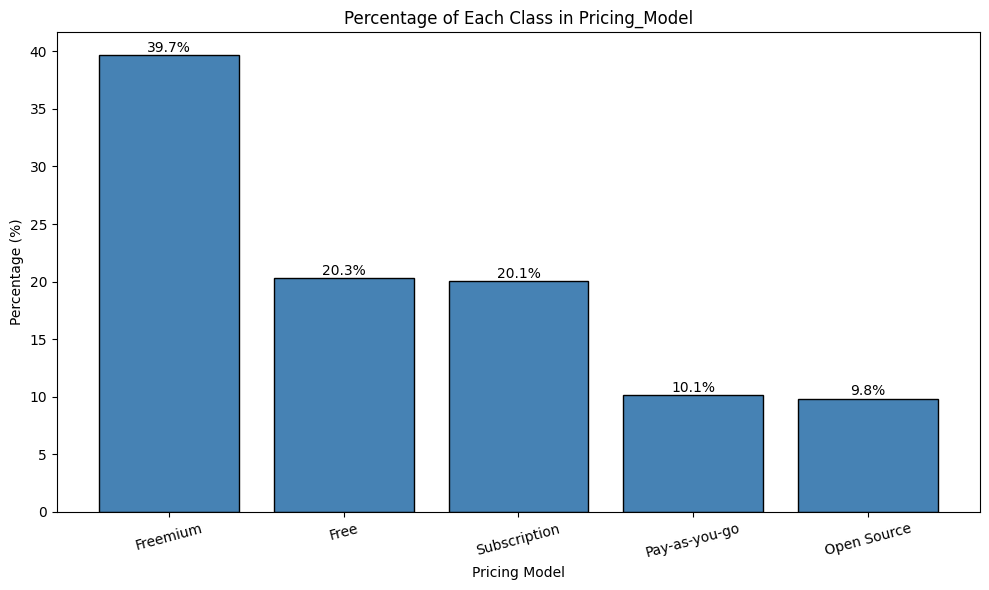

In [8]:
# --- Bar chart of class distribution ---
# From 3.1: adapted from the pie chart cell

plt.figure(figsize=(10, 6))
plt.bar(class_percentages.index, class_percentages.values, color='steelblue', edgecolor='black')
plt.title('Percentage of Each Class in Pricing_Model')
plt.xlabel('Pricing Model')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
for i, v in enumerate(class_percentages.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

class_distribution helper function

In [9]:
# --- Helper function to print class distribution ---
# From 3.1: class_distribution() function, copied exactly

def class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    total_samples = len(y)
    percentages = (counts / total_samples) * 100
    distribution = dict(zip(unique, zip(counts, percentages)))

    for class_label, (count, percentage) in distribution.items():
        print(f'Class {class_label}: {count} samples, {percentage:.2f}% of the dataset')

run_pipeline helper function

In [10]:
# --- Helper function to run and evaluate a pipeline ---
# From 3.2: run_pipeline() function, copied exactly, 
# adapted to use macro averaging since this is multiclass

def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("Experiment name: " + exp_name)
    print("Accuracy:  ", round(accuracy_score(y_test, y_pred), 4))
    print("Precision: ", round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("Recall:    ", round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("F1:        ", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print(f"Predicted class distribution:\n{pd.Series(y_pred).value_counts()}")
    print()

Baseline: no mitigation

In [11]:
# --- Baseline: no imbalance mitigation ---
# From 3.2: same structure as run_pipeline experiments

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("=" * 50)
print("BASELINE — No mitigation")
print("=" * 50)
class_distribution(y_train_encoded)   # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

pipe_baseline = LogisticRegression(max_iter=1000, random_state=42)
run_pipeline(pipe_baseline, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "Baseline (no mitigation)")       # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

BASELINE — No mitigation
Class 0: 3141 samples, 20.31% of the dataset
Class 1: 6132 samples, 39.66% of the dataset
Class 2: 1521 samples, 9.84% of the dataset
Class 3: 1568 samples, 10.14% of the dataset
Class 4: 3101 samples, 20.05% of the dataset
Experiment name: Baseline (no mitigation)
Accuracy:   0.3963
Precision:  0.0793 (macro)
Recall:     0.2 (macro)
F1:         0.1135 (macro)
Predicted class distribution:
1    1933
Name: count, dtype: int64



class_weight='balanced'

In [12]:
# --- class_weight='balanced' ---
# From 3.1: LogisticRegression(class_weight='balanced') pattern

print("=" * 50)
print("CLASS WEIGHT — balanced")
print("=" * 50)

pipe_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
run_pipeline(pipe_balanced, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "class_weight='balanced'")       # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

CLASS WEIGHT — balanced
Experiment name: class_weight='balanced'
Accuracy:   0.1733
Precision:  0.1905 (macro)
Recall:     0.1859 (macro)
F1:         0.1665 (macro)
Predicted class distribution:
2    508
3    408
0    380
4    345
1    292
Name: count, dtype: int64



 Oversampling techniques compared

In [13]:
# --- Oversampling and combined techniques compared ---
# From 3.2: Exercise 1 run_pipeline loop pattern, using ImbPipeline

print("=" * 50)
print("RESAMPLING TECHNIQUES COMPARISON")
print("=" * 50)

samplers = [
    (RandomOverSampler(random_state=42),  "RandomOverSampler"),
    (SMOTE(random_state=42),              "SMOTE"),
    (ADASYN(random_state=42),             "ADASYN"),
    (RandomUnderSampler(random_state=42), "RandomUnderSampler"),
    (SMOTEENN(random_state=42),           "SMOTEENN"),
    (SMOTETomek(random_state=42),         "SMOTETomek"),
]

for sampler, name in samplers:
    pipe = ImbPipeline([
        ('resample',    sampler),
        ('classifier',  LogisticRegression(max_iter=1000, random_state=42)),
    ])
    run_pipeline(pipe, X_train_processed, X_test_processed,
                 y_train_encoded, y_test_encoded, name)      # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

RESAMPLING TECHNIQUES COMPARISON
Experiment name: RandomOverSampler
Accuracy:   0.1728
Precision:  0.2036 (macro)
Recall:     0.1999 (macro)
F1:         0.1706 (macro)
Predicted class distribution:
2    513
0    467
3    409
4    356
1    188
Name: count, dtype: int64

Experiment name: SMOTE
Accuracy:   0.1516
Precision:  0.185 (macro)
Recall:     0.1822 (macro)
F1:         0.1489 (macro)
Predicted class distribution:
2    652
0    413
3    366
4    335
1    167
Name: count, dtype: int64

Experiment name: ADASYN
Accuracy:   0.1837
Precision:  0.2042 (macro)
Recall:     0.1998 (macro)
F1:         0.174 (macro)
Predicted class distribution:
0    540
2    504
3    412
1    258
4    219
Name: count, dtype: int64

Experiment name: RandomUnderSampler
Accuracy:   0.2157
Precision:  0.1948 (macro)
Recall:     0.1965 (macro)
F1:         0.1879 (macro)
Predicted class distribution:
1    529
2    405
0    403
4    307
3    289
Name: count, dtype: int64

Experiment name: SMOTEENN
Accuracy:   0.107

Class distribution after best resampler

In [ ]:
# --- Inspect class distribution after resampling ---
# From 3.1: class_distribution() usage after fit_resample

# SMOTE (usado anteriormente en Point 2 para comparación)
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train_processed, y_train_encoded)

# ADASYN (elegido para Point 3 por ser el mejor método de oversampling según resultados)
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train_processed, y_train_encoded)

print("Class distribution BEFORE resampling:")
class_distribution(y_train_encoded)
print("\nClass distribution AFTER ADASYN resampling:")
class_distribution(y_resampled)

Class distribution BEFORE resampling:
Class 0: 3141 samples, 20.31% of the dataset
Class 1: 6132 samples, 39.66% of the dataset
Class 2: 1521 samples, 9.84% of the dataset
Class 3: 1568 samples, 10.14% of the dataset
Class 4: 3101 samples, 20.05% of the dataset

Class distribution AFTER SMOTE resampling:
Class 0: 6132 samples, 20.00% of the dataset
Class 1: 6132 samples, 20.00% of the dataset
Class 2: 6132 samples, 20.00% of the dataset
Class 3: 6132 samples, 20.00% of the dataset
Class 4: 6132 samples, 20.00% of the dataset


PARTE DE 3.3 (3.4 NO NOS SIRVE)

Missingness analysis

In [15]:
# From 3.3: same pattern as df.isnull().sum() block
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2)[df.isnull().sum() > 0])

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
Context_Window    3877
dtype: int64

Missing values (%):
Context_Window    20.06
dtype: float64

Total missing values in dataset: 3877


Missingno matrix and heatmap

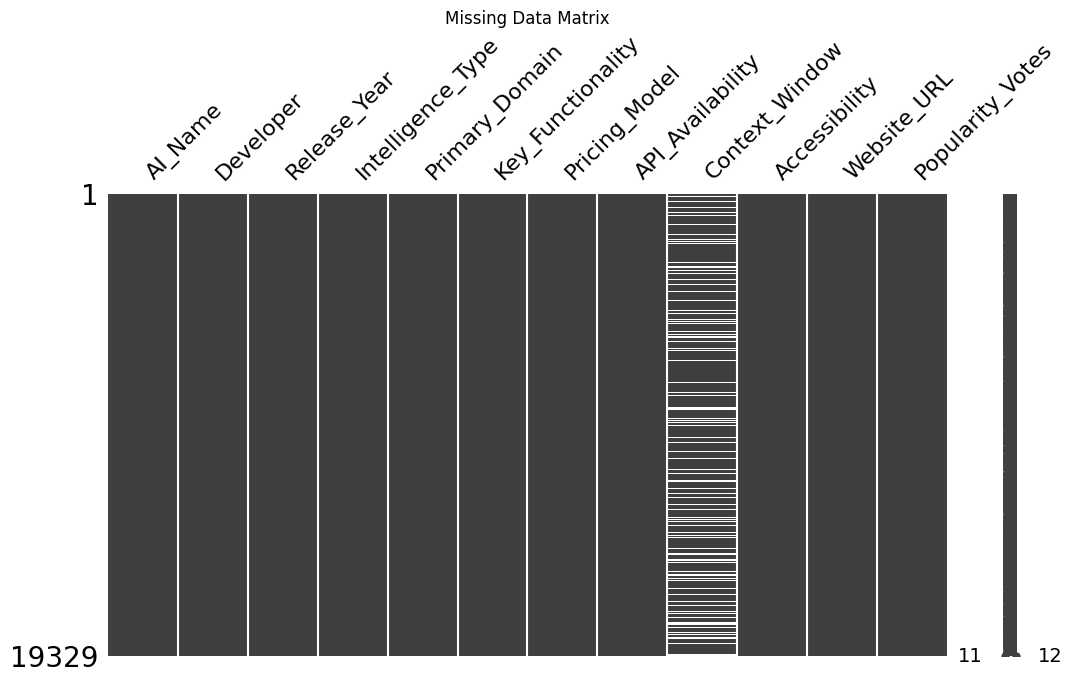

In [16]:
# From 3.3 Exercise 1: missingno matrix and heatmap, copied exactly

msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix')
plt.show()

Distribution of Context_Window before imputation

In [17]:
# From 3.3: compare_distributions helper, copied exactly

def compare_distributions(original, imputed, imputing_technique, feature):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(original[feature].dropna(), kde=False, color="blue", label="Original")
    plt.title('Original {} Distribution'.format(feature))
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(imputed[feature].dropna(), kde=False, color="green",
                 label="{} Imputed".format(imputing_technique))
    plt.title('{} Imputed {} Distribution'.format(imputing_technique, feature))
    plt.legend()

    plt.tight_layout()
    plt.show()

In [18]:
# 1. Crear la variable indicadora
df['Has_Context_Window'] = df['Context_Window'].notna().astype(int)

MODEL COMPARISON AND HYPERPARAMETER TUNING

In [ ]:
# le, y_train_encoded, y_test_encoded, X_resampled, y_resampled
# are all defined in Point 2 — no need to redefine them here.

optuna.logging.set_verbosity(optuna.logging.WARNING)

# We store each study here so we can retrieve best params in the final cell
studies = {}

def build_model(name, params):
    """Reconstruct a model using the best params found by its Optuna study."""
    if name == "VotingSoft":
        return VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=params["rf_n_estimators"], random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            voting='soft'
        )
    elif name == "Bagging":
        return BaggingClassifier( #Tiene DecisionTreeClassifier por defecto.
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            max_features=params["max_features"], #porque usa max_features en vez de max_samples? En collab usa oob_score y le mete un DecisionTree de estimator.
            random_state=42
        )
    elif name == "AdaBoost":
        return AdaBoostClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"], #Decision tree con max_depth=1 por defecto.
            random_state=42
        )
    elif name == "GradientBoosting":
        return GradientBoostingClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"], #subsample controla qué fracción de muestras se usa para entrenar cada árbol. Si es menor que 1.0 se convierte en Stochastic Gradient Boosting, que añade aleatoriedad y reduce overfitting.(Aporta regularización)
            subsample=params["subsample"],
            random_state=42
        )
    elif name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"], 
            random_state=42,
            eval_metric='mlogloss',
            verbosity=0
        )
    elif name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            max_features=params["max_features"],
            min_samples_split=params["min_samples_split"],  #Con datasets grandes como el vuestro puede ayudar a regularizar el modelo y evitar overfitting
            random_state=42
        )
    else:  # Stacking
        return StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            final_estimator=LogisticRegression(
                C=params["C"],
                max_iter=1000,     #C, max_iter, random_state en final_estimator y cv C es el hiperparámetro que Optuna tunea para el meta-learner — controla la regularización de LogisticRegression. max_iter=1000 es por la misma razón que en VotingSoft — evitar warnings de convergencia. random_state=42 es para reproducibilidad. cv=3 controla cuántos folds usa StackingClassifier internamente para generar las predicciones del meta-learner — el default es 5, lo bajamos a 3 para que sea más rápido. El collab no los mete porque es un ejemplo simplificado, pero en producción son buenas prácticas.(Sin cv tarda muchisimo)               random_state=42
            ),
            cv=3
        )

def make_progress_callback(model_name, n_trials):
    import time
    import threading

    start_time = time.time()
    lock = threading.Lock()
    printed = set()

    def callback(study, trial):
        with lock:
            completed = len([t for t in study.trials if t.state.name == "COMPLETE"])
            if completed in printed:
                return
            printed.add(completed)

            elapsed   = time.time() - start_time
            avg       = elapsed / completed
            remaining = avg * (n_trials - completed)

            print(
                f"[{model_name}] "
                f"Trial {completed:>3}/{n_trials} | "
                f"F1: {trial.value:.4f} | "
                f"Best: {study.best_value:.4f} | "
                f"~{remaining/60:.1f} min restantes"
            )

    return callback

In [ ]:
def objective_bagging(trial):
    clf = BaggingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 10, 200),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        max_features=trial.suggest_float("max_features", 0.5, 1.0),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=1).mean()

print("Optimizing Bagging...")
study_bag = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_bag.optimize(
    objective_bagging,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("Bagging", N_TRIALS_PER_MODEL)]
)
studies["Bagging"] = study_bag
print(f"  Best CV F1: {study_bag.best_value:.4f}  |  Best params: {study_bag.best_params}")

Optimizing Bagging...
[Bagging] Trial   1/50 | F1: 0.4312 | Best: 0.4312 | ~25.2 min restantes
[Bagging] Trial   2/50 | F1: 0.4277 | Best: 0.4312 | ~12.7 min restantes
[Bagging] Trial   3/50 | F1: 0.4626 | Best: 0.4626 | ~8.4 min restantes
[Bagging] Trial   4/50 | F1: 0.4542 | Best: 0.4626 | ~6.2 min restantes
[Bagging] Trial   5/50 | F1: 0.4630 | Best: 0.4630 | ~4.9 min restantes
[Bagging] Trial   6/50 | F1: 0.4298 | Best: 0.4630 | ~4.0 min restantes
[Bagging] Trial   7/50 | F1: 0.4508 | Best: 0.4630 | ~3.3 min restantes
[Bagging] Trial   8/50 | F1: 0.3875 | Best: 0.4630 | ~2.9 min restantes
[Bagging] Trial   9/50 | F1: 0.4143 | Best: 0.4630 | ~2.5 min restantes
[Bagging] Trial  10/50 | F1: 0.4583 | Best: 0.4630 | ~2.2 min restantes
[Bagging] Trial  11/50 | F1: 0.4126 | Best: 0.4630 | ~2.0 min restantes
[Bagging] Trial  12/50 | F1: 0.4133 | Best: 0.4630 | ~1.8 min restantes
[Bagging] Trial  13/50 | F1: 0.4524 | Best: 0.4630 | ~1.6 min restantes
[Bagging] Trial  14/50 | F1: 0.4642 | Be

In [ ]:
def objective_adaboost(trial):
    clf = AdaBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 2.0, log=True),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=-1).mean()

print("Optimizing AdaBoost...")
study_ada = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_ada.optimize(
    objective_adaboost,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("AdaBoost", N_TRIALS_PER_MODEL)]
)
studies["AdaBoost"] = study_ada
print(f"  Best CV F1: {study_ada.best_value:.4f}  |  Best params: {study_ada.best_params}")

Optimizing AdaBoost...
[AdaBoost] Trial   1/50 | F1: 0.2342 | Best: 0.2342 | ~1.7 min restantes
[AdaBoost] Trial   2/50 | F1: 0.2463 | Best: 0.2463 | ~0.9 min restantes
[AdaBoost] Trial   3/50 | F1: 0.2271 | Best: 0.2463 | ~0.7 min restantes
[AdaBoost] Trial   4/50 | F1: 0.2191 | Best: 0.2463 | ~0.6 min restantes
[AdaBoost] Trial   5/50 | F1: 0.1447 | Best: 0.2463 | ~0.5 min restantes
[AdaBoost] Trial   6/50 | F1: 0.1124 | Best: 0.2463 | ~0.5 min restantes
[AdaBoost] Trial   7/50 | F1: 0.1955 | Best: 0.2463 | ~0.4 min restantes
[AdaBoost] Trial   8/50 | F1: 0.1120 | Best: 0.2463 | ~0.5 min restantes
[AdaBoost] Trial   9/50 | F1: 0.1850 | Best: 0.2463 | ~0.4 min restantes
[AdaBoost] Trial  10/50 | F1: 0.1276 | Best: 0.2463 | ~0.4 min restantes
[AdaBoost] Trial  11/50 | F1: 0.2510 | Best: 0.2510 | ~0.5 min restantes
[AdaBoost] Trial  12/50 | F1: 0.1276 | Best: 0.2510 | ~0.5 min restantes
[AdaBoost] Trial  13/50 | F1: 0.2473 | Best: 0.2510 | ~0.4 min restantes
[AdaBoost] Trial  14/50 | F1

In [ ]:
def objective_votingsoft(trial):
    clf = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
                random_state=42
            )),
            # probability=True is required for soft voting — SVC does not
            # output probabilities by default, but soft voting needs them
            # to average class probabilities across estimators.
            ('svc', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=-1).mean()

print("Optimizing VotingSoft...")
study_vs = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_vs.optimize(
    objective_votingsoft,
    n_trials=20,
    n_jobs=-1,
    callbacks=[make_progress_callback("VotingSoft", 20)]
)
studies["VotingSoft"] = study_vs
print(f"  Best CV F1: {study_vs.best_value:.4f}  |  Best params: {study_vs.best_params}")

Optimizing VotingSoft...
[VotingSoft] Trial   1/20 | F1: 0.4668 | Best: 0.4668 | ~76.2 min restantes
[VotingSoft] Trial   2/20 | F1: 0.4686 | Best: 0.4686 | ~39.9 min restantes
[VotingSoft] Trial   3/20 | F1: 0.4684 | Best: 0.4686 | ~32.2 min restantes
[VotingSoft] Trial   4/20 | F1: 0.4687 | Best: 0.4687 | ~23.2 min restantes
[VotingSoft] Trial   5/20 | F1: 0.4675 | Best: 0.4687 | ~18.5 min restantes
[VotingSoft] Trial   6/20 | F1: 0.4690 | Best: 0.4690 | ~18.9 min restantes
[VotingSoft] Trial   7/20 | F1: 0.4670 | Best: 0.4690 | ~15.2 min restantes
[VotingSoft] Trial   8/20 | F1: 0.4691 | Best: 0.4691 | ~13.6 min restantes
[VotingSoft] Trial   9/20 | F1: 0.4650 | Best: 0.4691 | ~13.5 min restantes
[VotingSoft] Trial  10/20 | F1: 0.4685 | Best: 0.4691 | ~11.3 min restantes
[VotingSoft] Trial  11/20 | F1: 0.4669 | Best: 0.4691 | ~9.4 min restantes
[VotingSoft] Trial  12/20 | F1: 0.4688 | Best: 0.4691 | ~7.8 min restantes
[VotingSoft] Trial  13/20 | F1: 0.4679 | Best: 0.4691 | ~6.4 min 

In [ ]:
def objective_gradientboosting(trial):
    clf = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=-1).mean()

print("Optimizing GradientBoosting...")
study_gb = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_gb.optimize(
    objective_gradientboosting,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("GradientBoosting", N_TRIALS_PER_MODEL)]
)
studies["GradientBoosting"] = study_gb
print(f"  Best CV F1: {study_gb.best_value:.4f}  |  Best params: {study_gb.best_params}")

Optimizing GradientBoosting...
[GradientBoosting] Trial   1/50 | F1: 0.3341 | Best: 0.3341 | ~8.4 min restantes
[GradientBoosting] Trial   2/50 | F1: 0.2811 | Best: 0.3341 | ~4.3 min restantes
[GradientBoosting] Trial   3/50 | F1: 0.2749 | Best: 0.3341 | ~4.4 min restantes
[GradientBoosting] Trial   4/50 | F1: 0.2876 | Best: 0.3341 | ~3.5 min restantes
[GradientBoosting] Trial   5/50 | F1: 0.3074 | Best: 0.3341 | ~3.3 min restantes
[GradientBoosting] Trial   6/50 | F1: 0.2951 | Best: 0.3341 | ~2.9 min restantes
[GradientBoosting] Trial   7/50 | F1: 0.2674 | Best: 0.3341 | ~2.7 min restantes
[GradientBoosting] Trial   8/50 | F1: 0.2986 | Best: 0.3341 | ~2.9 min restantes
[GradientBoosting] Trial   9/50 | F1: 0.2701 | Best: 0.3341 | ~2.7 min restantes
[GradientBoosting] Trial  10/50 | F1: 0.2433 | Best: 0.3341 | ~2.5 min restantes
[GradientBoosting] Trial  11/50 | F1: 0.2975 | Best: 0.3341 | ~2.3 min restantes
[GradientBoosting] Trial  12/50 | F1: 0.2936 | Best: 0.3341 | ~2.3 min restant

In [ ]:
def objective_xgboost(trial):
    clf = xgb.XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=-1).mean()

print("Optimizing XGBoost...")
study_xgb = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_xgb.optimize(
    objective_xgboost,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("XGBoost", N_TRIALS_PER_MODEL)]
)
studies["XGBoost"] = study_xgb
print(f"  Best CV F1: {study_xgb.best_value:.4f}  |  Best params: {study_xgb.best_params}")

Optimizing XGBoost...
[XGBoost] Trial   1/50 | F1: 0.2628 | Best: 0.2628 | ~1.7 min restantes
[XGBoost] Trial   2/50 | F1: 0.3566 | Best: 0.3566 | ~1.1 min restantes
[XGBoost] Trial   3/50 | F1: 0.3099 | Best: 0.3566 | ~0.7 min restantes
[XGBoost] Trial   4/50 | F1: 0.2958 | Best: 0.3566 | ~0.8 min restantes
[XGBoost] Trial   5/50 | F1: 0.3704 | Best: 0.3704 | ~0.9 min restantes
[XGBoost] Trial   6/50 | F1: 0.4019 | Best: 0.4019 | ~0.8 min restantes
[XGBoost] Trial   7/50 | F1: 0.3817 | Best: 0.4019 | ~0.7 min restantes
[XGBoost] Trial   8/50 | F1: 0.3137 | Best: 0.4019 | ~0.8 min restantes
[XGBoost] Trial   9/50 | F1: 0.2782 | Best: 0.4019 | ~0.8 min restantes
[XGBoost] Trial  10/50 | F1: 0.3395 | Best: 0.4019 | ~0.8 min restantes
[XGBoost] Trial  11/50 | F1: 0.2801 | Best: 0.4019 | ~0.7 min restantes
[XGBoost] Trial  12/50 | F1: 0.3260 | Best: 0.4019 | ~0.7 min restantes
[XGBoost] Trial  13/50 | F1: 0.3147 | Best: 0.4019 | ~0.7 min restantes
[XGBoost] Trial  14/50 | F1: 0.3255 | Best

In [ ]:
def objective_randomforest(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=1).mean()

print("Optimizing RandomForest...")
study_rf = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_rf.optimize(
    objective_randomforest,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("RandomForest", N_TRIALS_PER_MODEL)]
)
studies["RandomForest"] = study_rf
print(f"  Best CV F1: {study_rf.best_value:.4f}  |  Best params: {study_rf.best_params}")

Optimizing RandomForest...
[RandomForest] Trial   1/50 | F1: 0.2605 | Best: 0.2605 | ~7.0 min restantes
[RandomForest] Trial   2/50 | F1: 0.4432 | Best: 0.4432 | ~3.5 min restantes
[RandomForest] Trial   3/50 | F1: 0.3430 | Best: 0.4432 | ~2.7 min restantes
[RandomForest] Trial   4/50 | F1: 0.2061 | Best: 0.4432 | ~2.1 min restantes
[RandomForest] Trial   5/50 | F1: 0.4279 | Best: 0.4432 | ~1.9 min restantes
[RandomForest] Trial   6/50 | F1: 0.2386 | Best: 0.4432 | ~1.9 min restantes
[RandomForest] Trial   7/50 | F1: 0.4706 | Best: 0.4706 | ~1.7 min restantes
[RandomForest] Trial   8/50 | F1: 0.3673 | Best: 0.4706 | ~1.6 min restantes
[RandomForest] Trial   9/50 | F1: 0.2436 | Best: 0.4706 | ~1.5 min restantes
[RandomForest] Trial  10/50 | F1: 0.3330 | Best: 0.4706 | ~1.3 min restantes
[RandomForest] Trial  11/50 | F1: 0.2830 | Best: 0.4706 | ~1.2 min restantes
[RandomForest] Trial  12/50 | F1: 0.2978 | Best: 0.4706 | ~1.1 min restantes
[RandomForest] Trial  13/50 | F1: 0.3336 | Best: 

In [ ]:
def objective_stacking(trial):
    clf = StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42))
        ],
        final_estimator=LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 10.0, log=True),
            max_iter=1000,
            random_state=42
        ),
        cv=3
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=5, scoring='f1_macro', n_jobs=-1).mean()

print("Optimizing Stacking...")
study_stack = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_stack.optimize(
    objective_stacking,
    n_trials=20,
    n_jobs=-1,
    callbacks=[make_progress_callback("Stacking", 20)]
)
studies["Stacking"] = study_stack
print(f"  Best CV F1: {study_stack.best_value:.4f}  |  Best params: {study_stack.best_params}")

Optimizing Stacking...
[Stacking] Trial   1/20 | F1: 0.4681 | Best: 0.4681 | ~125.5 min restantes
[Stacking] Trial   2/20 | F1: 0.4667 | Best: 0.4681 | ~71.4 min restantes
[Stacking] Trial   3/20 | F1: 0.4676 | Best: 0.4681 | ~46.1 min restantes
[Stacking] Trial   4/20 | F1: 0.4664 | Best: 0.4681 | ~39.6 min restantes
[Stacking] Trial   5/20 | F1: 0.4668 | Best: 0.4681 | ~39.7 min restantes
[Stacking] Trial   6/20 | F1: 0.4692 | Best: 0.4692 | ~34.3 min restantes
[Stacking] Trial   7/20 | F1: 0.4667 | Best: 0.4692 | ~27.4 min restantes
[Stacking] Trial   8/20 | F1: 0.4670 | Best: 0.4692 | ~22.3 min restantes
[Stacking] Trial   9/20 | F1: 0.4669 | Best: 0.4692 | ~25.9 min restantes
[Stacking] Trial  10/20 | F1: 0.4667 | Best: 0.4692 | ~21.4 min restantes
[Stacking] Trial  11/20 | F1: 0.4666 | Best: 0.4692 | ~17.7 min restantes
[Stacking] Trial  12/20 | F1: 0.4680 | Best: 0.4692 | ~15.1 min restantes
[Stacking] Trial  13/20 | F1: 0.4674 | Best: 0.4692 | ~12.6 min restantes
[Stacking] Tri

In [27]:
# ── FULL EVALUATION: VALIDATION SET (model selection) + TEST SET (final report) ──
# Workflow:
#   1. Train every model with its best Optuna hyperparameters on X_resampled / y_resampled
#   2. Evaluate ALL models on X_val_processed  → pick the best by F1 macro (validation)
#   3. Evaluate ONLY the best model on X_test_processed → final, unbiased result
#
# The test set is touched exactly once, only for the winner.
# Both val and test use the original class distribution (never resampled).
# We use macro averaging throughout — it treats all 5 classes equally.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report

# ── Encode val labels (same encoder fitted in Point 2) ────────────────────────
y_val_encoded = le.transform(y_val)

print("=" * 60)
print("STEP 1 — VALIDATION SET EVALUATION (model selection)")
print("=" * 60)

trained_models  = {}   # keep fitted models for test evaluation
val_rows        = []

for name, study in studies.items():
    best_params = study.best_params
    model = build_model(name, best_params)

    # Train on SMOTE-balanced data
    model.fit(X_resampled, y_resampled)
    trained_models[name] = model

    y_val_pred = model.predict(X_val_processed)

    acc  = accuracy_score(y_val_encoded, y_val_pred)
    prec = precision_score(y_val_encoded, y_val_pred, average='macro', zero_division=0)
    rec  = recall_score(y_val_encoded, y_val_pred, average='macro', zero_division=0)
    f1   = f1_score(y_val_encoded, y_val_pred, average='macro', zero_division=0)
    mcc  = matthews_corrcoef(y_val_encoded, y_val_pred)

    val_rows.append({
        "Model":      name,
        "Accuracy":   round(acc,  4),
        "Precision":  round(prec, 4),
        "Recall":     round(rec,  4),
        "F1 (macro)": round(f1,   4),
        "MCC":        round(mcc,  4),
    })

    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print(f"  Best params:  {best_params}")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  Precision:    {prec:.4f}  (macro)")
    print(f"  Recall:       {rec:.4f}  (macro)")
    print(f"  F1 Score:     {f1:.4f}  (macro)")
    print(f"  MCC:          {mcc:.4f}")

# ── Validation comparison table ───────────────────────────────────────────────
print()
print("=" * 60)
print("VALIDATION COMPARISON TABLE (sorted by F1 macro)")
print("=" * 60)

df_val = pd.DataFrame(val_rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
df_val.index += 1
print(df_val.to_string())

best_val_name = df_val.iloc[0]["Model"]
best_val_f1   = df_val.iloc[0]["F1 (macro)"]
print(f"\n→ Best model on VALIDATION: {best_val_name}  (F1 macro = {best_val_f1:.4f})")

# ── STEP 2: Test set — evaluated ONLY for the validation winner ───────────────
print()
print("=" * 60)
print(f"STEP 2 — TEST SET EVALUATION  (winner: {best_val_name})")
print("=" * 60)

best_model = trained_models[best_val_name]
y_test_pred = best_model.predict(X_test_processed)

acc  = accuracy_score(y_test_encoded, y_test_pred)
prec = precision_score(y_test_encoded, y_test_pred, average='macro', zero_division=0)
rec  = recall_score(y_test_encoded, y_test_pred, average='macro', zero_division=0)
f1   = f1_score(y_test_encoded, y_test_pred, average='macro', zero_division=0)
mcc  = matthews_corrcoef(y_test_encoded, y_test_pred)

print(f"  Model:        {best_val_name}")
print(f"  Accuracy:     {acc:.4f}")
print(f"  Precision:    {prec:.4f}  (macro)")
print(f"  Recall:       {rec:.4f}  (macro)")
print(f"  F1 Score:     {f1:.4f}  (macro)")
print(f"  MCC:          {mcc:.4f}")
print()
print(classification_report(y_test_encoded, y_test_pred, target_names=le.classes_))

print()
print("NOTE: All other models were NOT evaluated on the test set.")
print("The test set was touched exactly once, for the validation winner only.")

STEP 1 — VALIDATION SET EVALUATION (model selection)

────────────────────────────────────────
Model: Bagging
  Best params:  {'n_estimators': 170, 'max_samples': 0.6979897889897664, 'max_features': 0.9957007192444337}
  Accuracy:     0.2716
  Precision:    0.2238  (macro)
  Recall:       0.2254  (macro)
  F1 Score:     0.2242  (macro)
  MCC:          0.0281

────────────────────────────────────────
Model: AdaBoost
  Best params:  {'n_estimators': 298, 'learning_rate': 1.4896325176529714}
  Accuracy:     0.2375
  Precision:    0.1898  (macro)
  Recall:       0.1967  (macro)
  F1 Score:     0.1854  (macro)
  MCC:          -0.0073

────────────────────────────────────────
Model: VotingSoft
  Best params:  {'rf_n_estimators': 197}
  Accuracy:     0.2628
  Precision:    0.2184  (macro)
  Recall:       0.2205  (macro)
  F1 Score:     0.2188  (macro)
  MCC:          0.0201

────────────────────────────────────────
Model: GradientBoosting
  Best params:  {'n_estimators': 161, 'learning_rate':